# MAD-X test

In [1]:
from cpymad.madx import Madx
from matplotlib import pyplot as plt
import pandas as pd
%config InlineBackend.figure_format = 'retina' # retina display

ModuleNotFoundError: No module named 'cpymad'

### Launching MAD-X

In [ ]:
myMad = Madx()



  +     MAD-X 5.09.00  (64 bit, Darwin)      +
  + Support: mad@cern.ch, http://cern.ch/mad +
  + Release   date: 2023.05.05               +
  + Execution date: 2023.11.22 15:12:30      +
  ++++++++++++++++++++++++++++++++++++++++++++


### Quadrupole Strengths

In [ ]:
myString='''
! *********************************************************************
! Quadrupole Strengths
! **

KQF1 := 0.10;
KQD1 :=-0.08;
KQF2 := 0.12;
KQD2 :=-0.1;
KQF3 := 0.0;
KQD3 := 0.0;
KQF4 := 0.2;
KQD4 :=-0.2;
KQF5 := 0;
KQD5 :=-0.1;
KQF6 := 0.23;

'''
myMad.input(myString);

### Definition of parameters

In [ ]:
myString='''
! *********************************************************************
! Definition of parameters
! *********************************************************************
DD1:  DRIFT, L=0.25;
DD2:  DRIFT, L=7.2188+5-3;
DD3:  DRIFT, L=7.2188+3;
DD4:  DRIFT, L=7.2188+5-4;
DD4A: DRIFT, L=6.0485;
DD4B: DRIFT, L=6.0485;
DD5:  DRIFT, L=7.2188-5+4;
DD6:  DRIFT, L=7.2188-5;
DD7:  DRIFT, L=5.4-4+1.2;
DD8:  DRIFT, L=5.4+3.5+4-4;
DD9:  DRIFT, L=12.097;
DD9A: DRIFT, L=5.4-3.5+4;
DD9B: DRIFT, L=5.403333333-2;
DD10: DRIFT, L=5.403333333-1;
DD11: DRIFT, L=5.403333333-0.6-1+0.6;
DD11A: DRIFT, L=4;
DD12: DRIFT, L=0.25;
DD13: DRIFT, L=0.25;
DD14: DRIFT, L=1.5;
DD15: DRIFT, L=1.5;
DD16: DRIFT, L=7.864641;
DRIFT_SEPTUM: DRIFT, L=0.200001;

'''
myMad.input(myString);

### Definition of the magnets

In [ ]:
myString='''
! *********************************************************************
! Definition of magnets
! *********************************************************************

GRDN:= 0.0380886;
ANG1U:= 0.048152417; ! For Downstream Use Only
ANG1D:= -0.048152417; ! For Upstream Use Only
LGD:= 3.6576;
TG2:= ANG1U/2.0;
LAGD:= (LGD/2.0)*ANG1U/SIN(TG2);
LARC:= LAGD/2;

XD3H:  SBEND, L=LARC, ANGLE=-ANG1U/2, K1=GRDN,  E1=0,    E2=-TG2;
XD4H1: SBEND, L=LARC, ANGLE=-ANG1U/2, K1=-GRDN, E1=-TG2, E2=0.0;
XD4H2: SBEND, L=LARC, ANGLE=-ANG1U/2, K1=-GRDN, E1=0.0,  E2=TG2;
XD5H:  SBEND, L=LARC, ANGLE=-ANG1U/2, K1=GRDN,  E1=-TG2, E2=0.0;

QUAD1: QUADRUPOLE, L=0.6, K1:=KQF1;
QUAD2: QUADRUPOLE, L=0.6, K1:=KQD1;
QUAD3: QUADRUPOLE, L=0.6, K1:=KQF2;
QUAD4: QUADRUPOLE, L=0.6, K1:=KQD2;
QUAD5: QUADRUPOLE, L=0.6, K1:=KQF3;
QUAD6: QUADRUPOLE, L=0.6, K1:=KQD3;
QUAD7: QUADRUPOLE, L=0.6, K1:=KQF4;
QUAD8: QUADRUPOLE, L=0.6, K1:=KQD4;
QUAD9: QUADRUPOLE, L=0.6, K1:=KQF5;
QUAD10: QUADRUPOLE, L=0.6, K1:=KQD5;
QUAD11: QUADRUPOLE, L=0.6, K1:=KQF6;

DIPOLE1: RBEND, L=2, ANGLE=-0.0301646;
DIPOLE2: RBEND, L=2, ANGLE=-0.0301615;
CURRENT_SEPTUM: RBEND, L=3.975981, ANGLE=0.05011;
INDUCT_SEPTUM: RBEND, L=1.5, ANGLE=0.01841;

SEPT_END: MARKER, L=0;
MSTART: MARKER, L=0;
MEND: MARKER, L=0;
'''
myMad.input(myString);

### Definition of the sequence

In [ ]:
myString='''
! *********************************************************************
! Definition of sequence
! *********************************************************************
myCell:sequence, refer=entry;
MSTART, DD1, XD4H1, XD4H1,
DD2, QUAD1, DD3, QUAD2, DD4,
QUAD3, DD5, QUAD4, DD6, DIPOLE1,
DD7, DD8, DD9A, DIPOLE2, DD9B,
QUAD7, DD10, QUAD8, DD11, DD11A,
XD3H, XD3H, DD12, DD13, XD4H1, XD4H1,
DD14, QUAD10, DD15, QUAD11, DD16,
CURRENT_SEPTUM, DRIFT_SEPTUM,
INDUCT_SEPTUM, SEPT_END, MEND,
endsequence;
'''
myMad.input(myString);

### Definition of the beam

In [ ]:
myString='''
! *********************************************************************
! Definition of beam
! *********************************************************************
beam, particle=proton, energy=25;
'''
myMad.input(myString);

### Initial Twiss Parameters

In [ ]:
myString='''
! *********************************************************************
! 9-CELL STRUCTURE
! *********************************************************************
KQ = 0.227252;
LQ = 0.6;
LDW = 12.097;
LD6 = 3.65;
L_GOAL = 36.85990677;
LD = L_GOAL - (2*LCF) - (2*LQ) - 0.5;

QF: QUADRUPOLE, L=LQ, K1=KQ;
QD: QUADRUPOLE, L=LQ, K1=-KQ;
UPQF: QUADRUPOLE, L=LQ, K1=0.4;
UPQD: QUADRUPOLE, L=LQ, K1=-0.4;

D1: DRIFT, L=0.25;
D2: DRIFT, L=12.097;
D3: DRIFT, L=3.65;
D4: DRIFT, L=12.097;
D5: DRIFT, L=0.25;

CELL: LINE = (D1, XD4H1, XD4H1, D2, QF, D3, QD, D4, XD3H, XD3H, D5);


'''
myMad.input(myString);

### Defining the Initial Condition

In [ ]:
myString='''
! *********************************************************************
! Initial Condition
! *********************************************************************
use, PERIOD=cell;
SAVEBETA, LABEL=END0, PLACE=#E;
twiss,table;
value, END0->betx,END0->bety,END0->alfx,END0->alfy,END0->dx,END0->dpx;

! In case SAVEBETA doesn't work
BXNINE	 := 18.41113503;
AXNINE	 := 2.036449399;
DXNINE	 := -0.6834457435;
DPXNINE	 := 0.0684285023;
BYNINE	 := 18.49891776;
AYNINE	 := -2.047332212;
DYNINE	 := 0;
DPYNINE	 := 0;

NINEND: BETA0, BETX:=BXNINE, ALFX:=AXNINE, DX:=DXNINE, DPX:=DPXNINE,
	       BETY:=BYNINE, ALFY:=AYNINE, DY:=DYNINE, DPY:=DPYNINE;
'''
myMad.input(myString);

### Matching

In [ ]:
myString='''
! *********************************************************************
! Matching
! *********************************************************************

USE, SEQUENCE = myCell;
BETX=65.1994;
BETY=9.2303;
ALFX=0.8753;
ALFY=-0.2563;
DX=0.0345;
DPX=0.0015;

match, SEQUENCE = myCell, use_macro;
       VARY, NAME = KQF1, STEP=0.00001, LOWER=-5, UPPER=5;
       VARY, NAME = KQD1, STEP=0.00001, LOWER=-5, UPPER=5;
       VARY, NAME = KQF2, STEP=0.00001, LOWER=-5, UPPER=5;
       VARY, NAME = KQD2, STEP=0.00001, LOWER=-5, UPPER=5;
       VARY, NAME = KQF3, STEP=0.00001, LOWER=-5, UPPER=5;
       VARY, NAME = KQD3, STEP=0.00001, LOWER=-5, UPPER=5;
       VARY, NAME = KQF4, STEP=0.00001, LOWER=-5, UPPER=5;
       VARY, NAME = KQD4, STEP=0.00001, LOWER=-5, UPPER=5;
       VARY, NAME = KQF5, STEP=0.00001, LOWER=-5, UPPER=5;
       VARY, NAME = KQD5, STEP=0.00001, LOWER=-5, UPPER=5;
       VARY, NAME = KQF6, STEP=0.00001, LOWER=-5, UPPER=5;

       m1:macro={
       savebeta, label=end,place=#E,sequence=myCell;
       TWISS, sequence=myCell,BETA0=END0;
             mvar1 = end->betx - BETX;
	      mvar2 = 2*(end->bety - BETY);
	      mvar3 = 20*(end->alfx - ALFX);
	      mvar4 = 20*(end->alfy - ALFY);
	      mvar5 = 40*(end->dx - DX);
	      mvar6 = 40*(end->dpx - DPX);
	      };

	constraint, expr=mvar1 = 0;
	constraint, expr=mvar2 = 0;
	constraint, expr=mvar3 = 0;
	constraint, expr=mvar4 = 0;
	constraint, expr=mvar5 = 0;
	constraint, expr=mvar6 = 0;
	!constraint, expr=dqf1->k1=0;
	!constraint, expr=mvar7 = 0;

	!constraint, range = xd3h/xd4h1, bety<25->type1;
	!constraint, range = mstart/mend, bety<50->type2;
	!constraint, range = mstart/mend, betx<50->type3;
	!constraint, range = SEPT_END, dx=0.0345->type4;

	JACOBIAN, CALLS=5000000, TOLERANCE=1.0E-12;
endmatch;

'''
myMad.input(myString);

### Activating the sequence

In [ ]:
myString='''
! *********************************************************************
! Use of the sequence without matching
! *********************************************************************
use, sequence=myCell;
'''
myMad.input(myString);

### Computing the periodic solution

In [ ]:
myString='''
! *********************************************************************
! TWISS
! *********************************************************************
title, 'HSR INJECTION DOWNSTREAM';
twiss, SEQUENCE = myCell, TABLE = TWISS, BETA0 = NINEND;
'''
myMad.input(myString);

enter Twiss module
  
iteration:   1 error:   0.000000E+00 deltap:   0.000000E+00
orbit:   0.000000E+00  0.000000E+00  0.000000E+00  0.000000E+00  0.000000E+00  0.000000E+00

++++++ table: summ

            length             orbit5               alfa            gammatr 
               100                 -0                  0                  0 

                q1                dq1            betxmax              dxmax 
     0.03853349451     -0.04384718845        463.6232883                  0 

             dxrms             xcomax             xcorms                 q2 
                 0                  0                  0      0.03853349451 

               dq2            betymax              dymax              dyrms 
    -0.04384718845        463.6232883                  0                  0 

            ycomax             ycorms             deltap            synch_1 
                 0                  0                  0                  0 

           synch_2            

### Accessing to the results

In [ ]:
myString='''
value, table(SUMM,Q1);
value, table(SUMM,betymax);
'''
myMad.input(myString);

table( summ q1 )   =      0.03853349451 ;
table( summ betymax ) =        463.6232883 ;


In [ ]:
# This require a bit of knowledge of pandas dataframes
myDF=myMad.table.twiss.dframe()
myDF[['name','s','betx','bety']]

,name,s,betx,bety
#s,mycell$start:1,0.0,463.623288,369.779162
quadrupole1,quadrupole1:1,5.0,463.623288,369.779162
drift_0[0],drift_0:0,25.0,419.394867,408.967742
marker1,marker1:1,25.0,419.394867,408.967742
drift_1[0],drift_1:0,50.0,369.779162,463.623288
quadrupole2,quadrupole2:1,55.0,369.779162,463.623288
drift_2[0],drift_2:0,100.0,463.623288,369.779162
#e,mycell$end:1,100.0,463.623288,369.779162


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Text(0.5, 1.0, 'My first FODO cell')

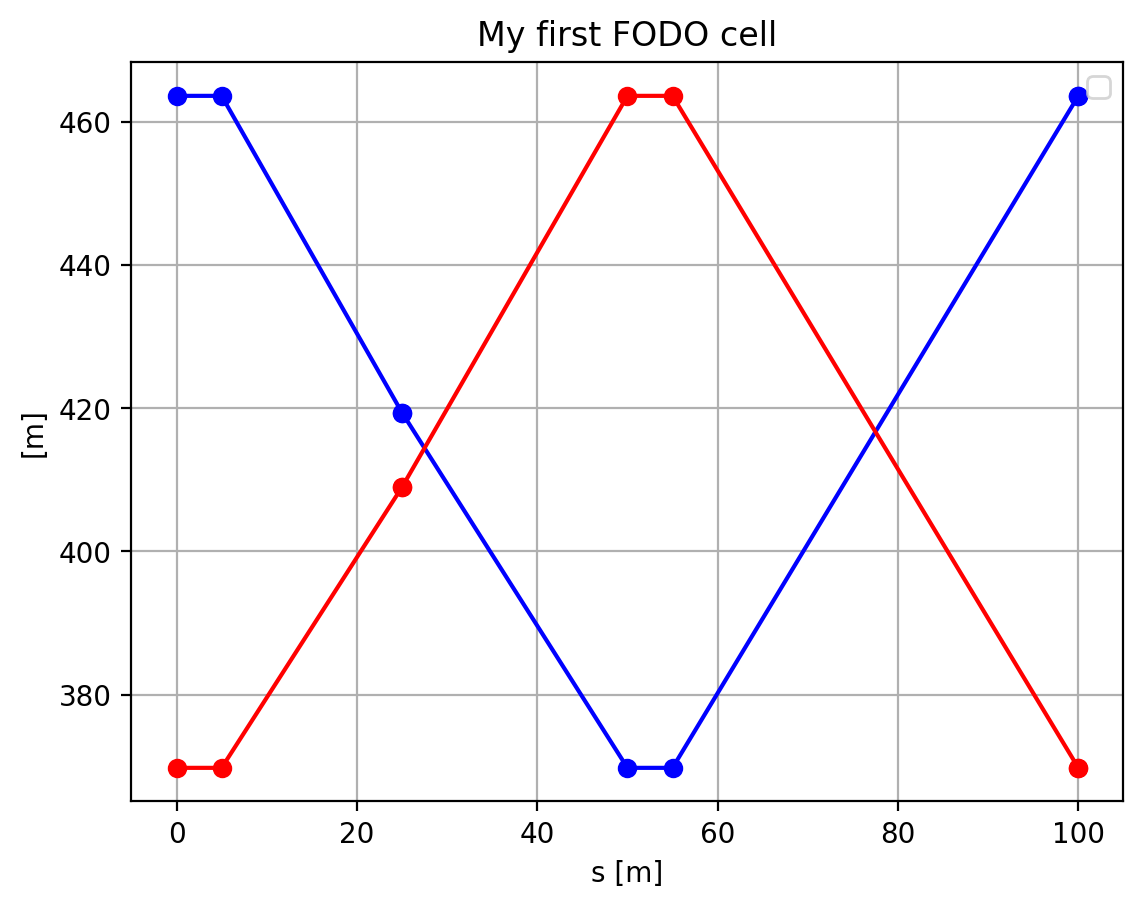

In [ ]:
plt.plot(myDF['s'],myDF['betx'],'ob-')
plt.plot(myDF['s'],myDF['bety'],'or-')
plt.legend()
plt.grid()
plt.xlabel('s [m]')
plt.ylabel('[m]')
plt.title('My first FODO cell')

### More advanced plotting

In [ ]:
import matplotlib.patches as patches

def plotLatticeSeries(ax,series, height=1., v_offset=0., color='r',alpha=0.5,lw=3):
    aux=series
    ax.add_patch(
    patches.Rectangle(
        (aux.s-aux.l, v_offset-height/2.),   # (x,y)
        aux.l,          # width
        height,          # height
        color=color, alpha=alpha,lw=lw
    )
    )
    return;

(-5.0, 150.0)

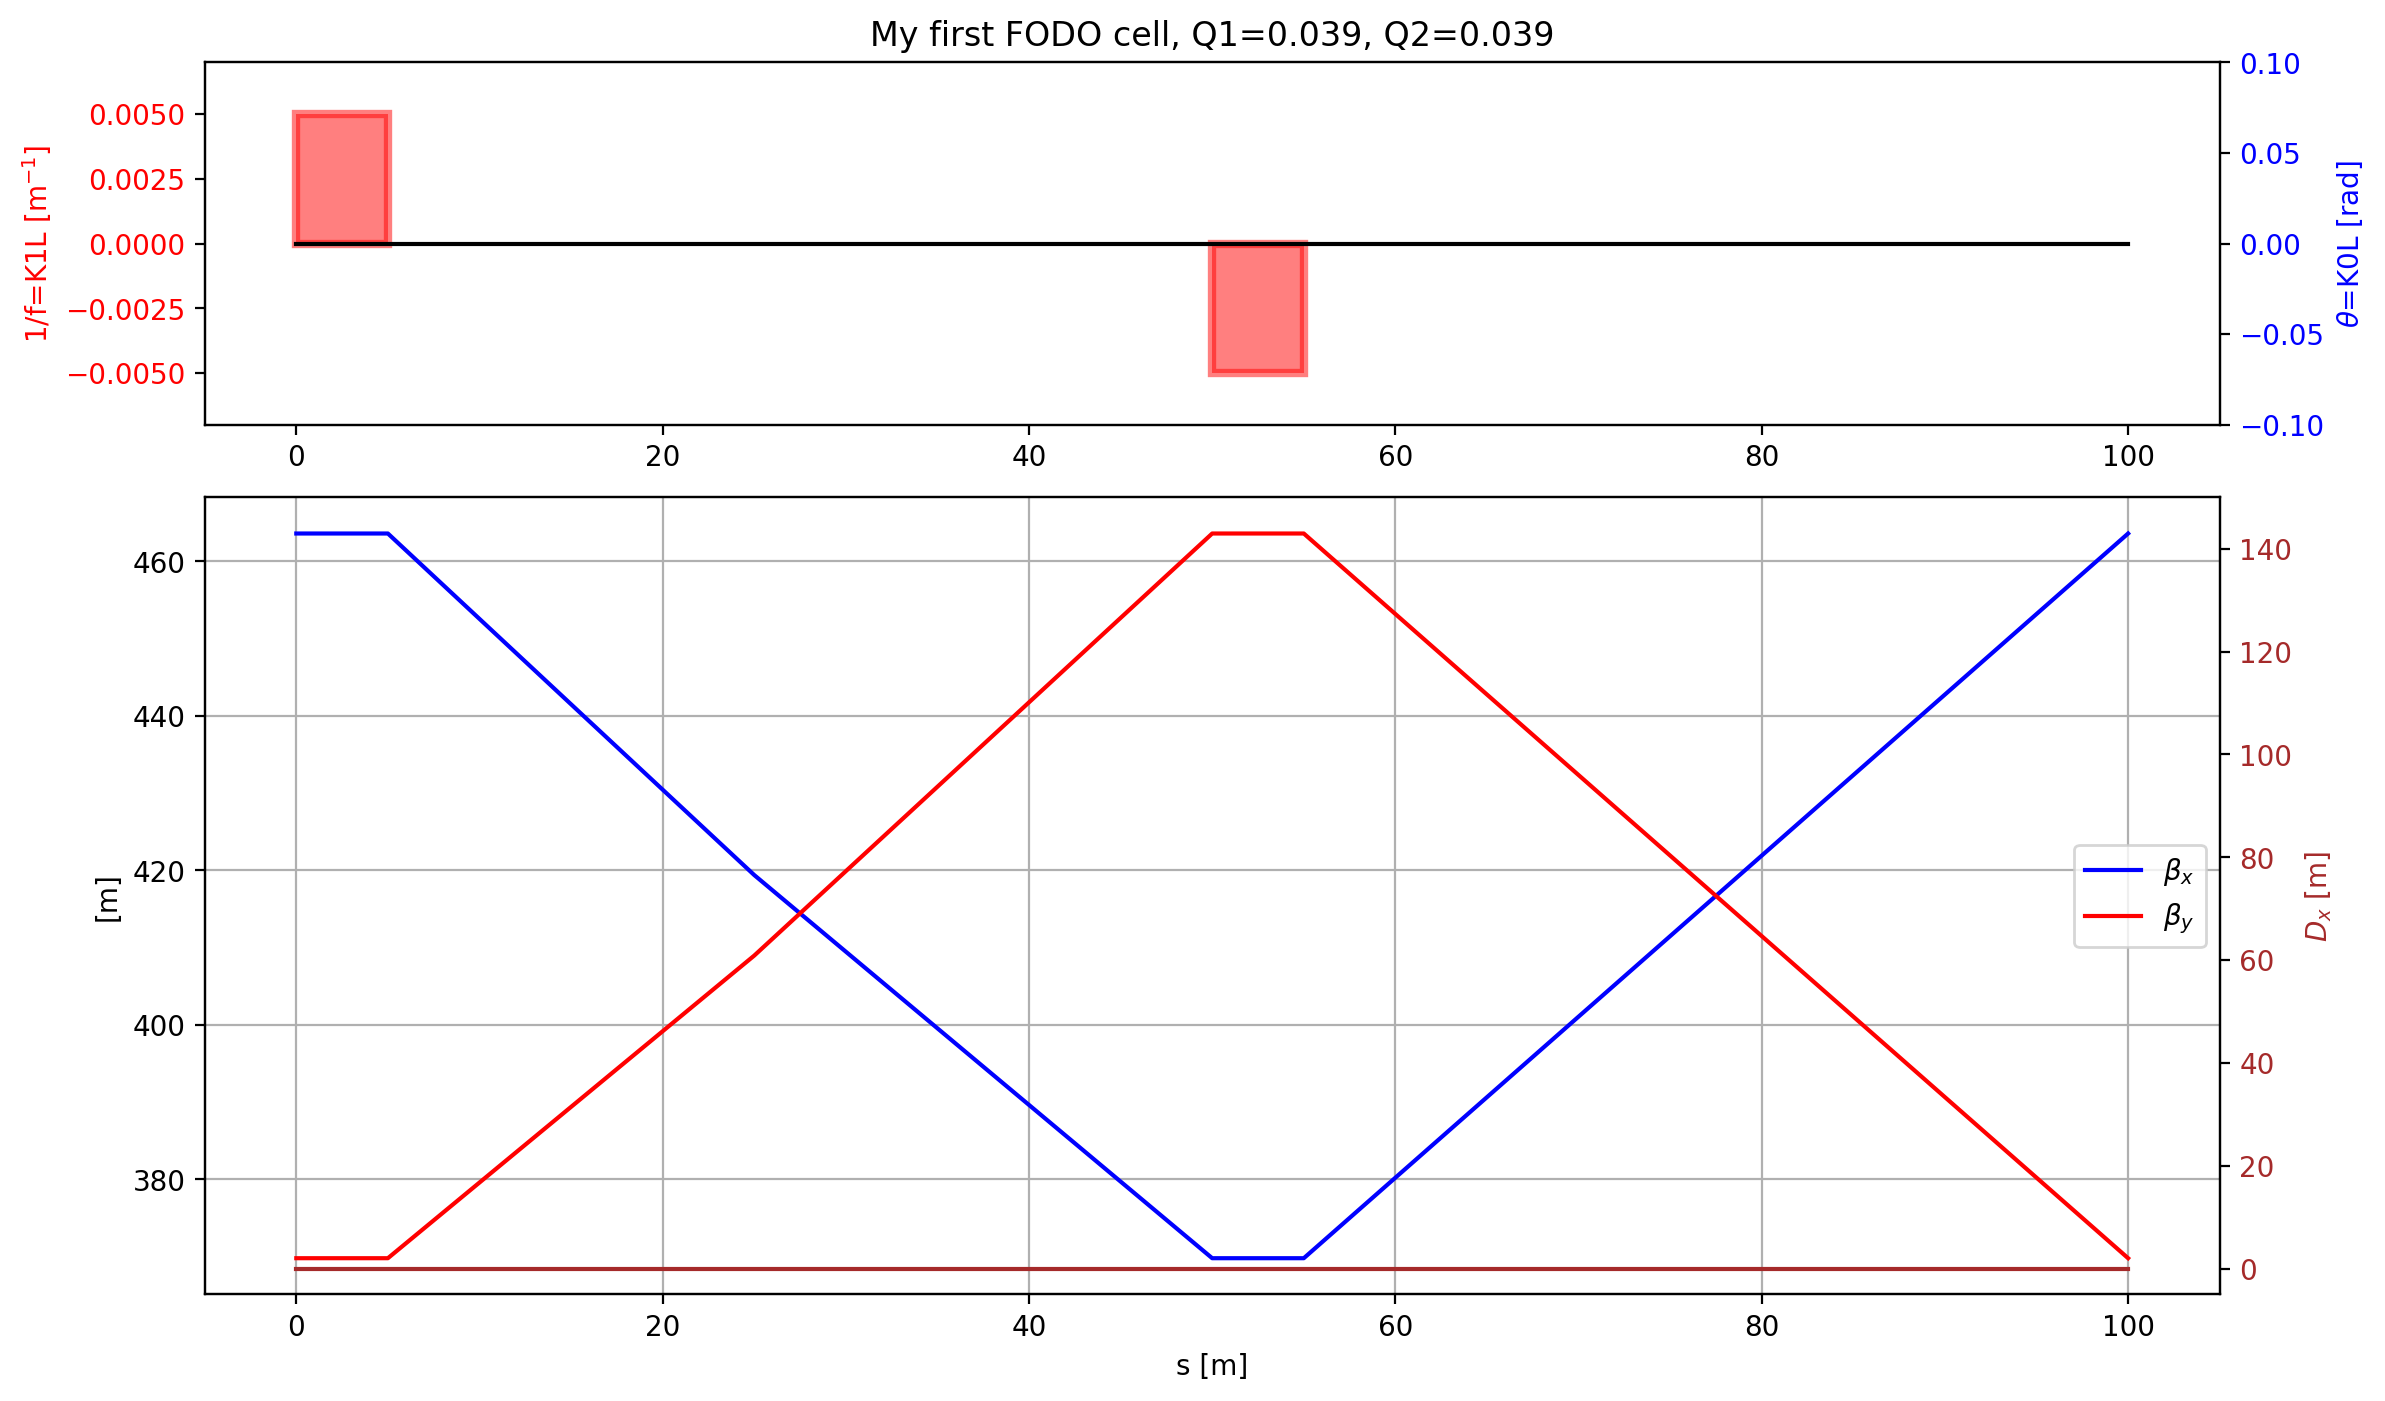

In [ ]:
myTwiss=myDF
# plotting the results
fig = plt.figure(figsize=(13,8))
# set up subplot grid
#gridspec.GridSpec(3,3)

ax1=plt.subplot2grid((3,3), (0,0), colspan=3, rowspan=1)
plt.plot(myTwiss['s'],0*myTwiss['s'],'k')


DF=myTwiss[(myTwiss['keyword']=='quadrupole')]
for i in range(len(DF)):
    aux=DF.iloc[i]
    plotLatticeSeries(plt.gca(),aux, height=aux.k1l, v_offset=aux.k1l/2, color='r')

DF=myTwiss[(myTwiss['keyword']=='multipole')]
for i in range(len(DF)):
    aux=DF.iloc[i]
    plotLatticeSeries(plt.gca(),aux, height=aux.k1l, v_offset=aux.k1l/2, color='r')


color = 'red'
ax1.set_ylabel('1/f=K1L [m$^{-1}$]', color=color)  # we already handled the x-label with ax1
ax1.tick_params(axis='y', labelcolor=color)
plt.ylim(-.007,.007)
plt.title('My first FODO cell, Q1='+format(myMad.table.summ.Q1[0],'2.3f')+', Q2='+ format(myMad.table.summ.Q2[0],'2.3f'))
ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

color = 'blue'
ax2.set_ylabel('$\\theta$=K0L [rad]', color=color)  # we already handled the x-label with ax1
ax2.tick_params(axis='y', labelcolor=color)


#DF=myTwiss[(myTwiss['keyword']=='sbend')]
#for i in range(len(DF)):
#    aux=DF.iloc[i]
#    plotLatticeSeries(ax2,aux, height=aux.angle*1000, v_offset=aux.angle*1000/2, color='b')

DF=myTwiss[(myTwiss['keyword']=='multipole')]
for i in range(len(DF)):
    aux=DF.iloc[i]
    plotLatticeSeries(plt.gca(),aux, height=aux.k0l, v_offset=aux.k0l/2, color='b')

plt.ylim(-.1,.1)

# large subplot
plt.subplot2grid((3,3), (1,0), colspan=3, rowspan=2,sharex=ax1)

plt.plot(myTwiss['s'],myTwiss['betx'],'b', label='$\\beta_x$')
plt.plot(myTwiss['s'],myTwiss['bety'],'r', label='$\\beta_y$')
plt.legend(loc='best')
plt.ylabel('[m]')
plt.xlabel('s [m]')
plt.grid()

ax3 = plt.gca().twinx()   # instantiate a second axes that shares the same x-axis
plt.plot(myTwiss['s'],myTwiss['dx'],'brown', label='$D_x$')
ax3.set_ylabel('$D_x$ [m]', color='brown')  # we already handled the x-label with ax1
ax3.tick_params(axis='y', labelcolor='brown')
plt.ylim(-5, 150)

# Some symbolic computation

In [ ]:
import sympy as sy
import numpy as np
from sympy import init_session
init_session()
la=np.linalg
L_cell=sy.Symbol('L_cell', positive=True);
f_1=sy.Symbol('f_1', positive=True);
f_2=sy.Symbol('f_2', positive=True);
f=sy.Symbol('f', positive=True);


QF=sy.Matrix([[1,0], [-1/f,1]])
DRIFT=sy.Matrix([[1,L_cell/2], [0,1]])
QD=sy.Matrix([[1,0], [1/f,1]])


IPython console for SymPy 1.11.1 (Python 3.11.6-64-bit) (ground types: gmpy)

These commands were executed:
>>> from sympy import *
>>> x, y, z, t = symbols('x y z t')
>>> k, m, n = symbols('k m n', integer=True)
>>> f, g, h = symbols('f g h', cls=Function)
>>> init_printing()

Documentation can be found at https://docs.sympy.org/1.11.1/



In [ ]:
# This is the OTM
M=DRIFT@QD@DRIFT@QF
M=sy.simplify(M)
M

⎡        2                     2         ⎤
⎢  L_cell    L_cell      L_cell          ⎥
⎢- ─────── - ────── + 1  ─────── + L_cell⎥
⎢       2     2⋅f          4⋅f           ⎥
⎢    4⋅f                                 ⎥
⎢                                        ⎥
⎢                           L_cell       ⎥
⎢                           ────── + f   ⎥
⎢       -L_cell               2          ⎥
⎢       ────────            ──────────   ⎥
⎢            2                  f        ⎥
⎣         2⋅f                            ⎦

# PyNAFF test

In [ ]:
import PyNAFF as pnf
import numpy as np

t = np.linspace(1, 3000, num=3000, endpoint=True)
Q = 0.12345
signal = np.sin(2.0*np.pi*Q*t)
pnf.naff(signal, 500, 1, 0 , False, window=1)
# outputs an array of arrays for each frequency. Each sub-array includes:
# [order of harmonic, frequency, Amplitude, Re{Amplitude}, Im{Amplitude]


# My frequency is simply
pnf.naff(signal, 500, 1, 0 , False)[0][1]

ModuleNotFoundError: No module named 'PyNAFF'

# Reset the starting point for the sequence

In [ ]:
myString='''
SEQEDIT,	SEQUENCE=myCell;
            FLATTEN;
            CYCLE, START=marker1;
ENDEDIT;
'''
myMad.input(myString);

++++++ info: seqedit - number of elements installed:  0
++++++ info: seqedit - number of elements moved:      0
++++++ info: seqedit - number of elements removed:    0
++++++ info: seqedit - number of elements replaced:   0


## Show twiss for the new sequence

In [ ]:
myString='''
! *********************************************************************
! TWISS
! *********************************************************************
use, sequence=myCell;
title, 'My first twiss';
twiss;
'''
myMad.input(myString);
myDF=myMad.table.twiss.dframe()
myDF[['name','s','betx','bety','x','y']]

enter Twiss module
  
iteration:   1 error:   0.000000E+00 deltap:   0.000000E+00
orbit:   0.000000E+00  0.000000E+00  0.000000E+00  0.000000E+00  0.000000E+00  0.000000E+00

++++++ table: summ

            length             orbit5               alfa            gammatr 
               100                 -0                  0                  0 

                q1                dq1            betxmax              dxmax 
     0.03853349451     -0.04384718845        463.6232883                  0 

             dxrms             xcomax             xcorms                 q2 
                 0                  0                  0      0.03853349451 

               dq2            betymax              dymax              dyrms 
    -0.04384718845        463.6232883                  0                  0 

            ycomax             ycorms             deltap            synch_1 
                 0                  0                  0                  0 

           synch_2            

,name,s,betx,bety,x,y
marker1,marker1:1,0.0,419.394867,408.967742,0.0,0.0
drift_0[0],drift_0:0,25.0,369.779162,463.623288,0.0,0.0
quadrupole2,quadrupole2:1,30.0,369.779162,463.623288,0.0,0.0
drift_1[0],drift_1:0,75.0,463.623288,369.779162,0.0,0.0
#e,mycell$end:1,75.0,463.623288,369.779162,0.0,0.0
#s,mycell$start:1,75.0,463.623288,369.779162,0.0,0.0
quadrupole1,quadrupole1:1,80.0,463.623288,369.779162,0.0,0.0
drift_2[0],drift_2:0,100.0,419.394867,408.967742,0.0,0.0
mycellmarker1_p_,mycellmarker1_p_:1,100.0,419.394867,408.967742,0.0,0.0


In [ ]:
myString='''
use, sequence=myCell;

ptc_create_universe;
ptc_create_layout,model=2,method=6,nst=10,exact;
//ptc_align;
ptc_twiss, x=0.003, y=0.001;

ptc_start, x= 0, px=0, y= 0, py=0, t=0, pt=0;

ptc_observe,place=quadrupole1;
ptc_observe,place=quadrupole2;

ptc_track,icase=6,closed_orbit,dump, // deltap=0.0D0
       element_by_element,
       turns=10, ffile=1, norm_no=1; // norm_out, norm_out

/*
ptc_track,icase=6,closed_orbit=1,dump, file, ffile=4,// deltap=0.0D0
       element_by_element=1, radiation=1, radiation_energy_loss=1, radiation_quad=1, //
       beam_envelope=1, turns=10, ffile=1, norm_no=1; // norm_out, norm_out
*/

//plot, file="fv9_4_START_obs1",ptc,table=track,haxis=x,vaxis=px,
//      particle=1,2,3,colour=1000, multiple, symbol=3;
//plot, file="fv9_4_START_obs1",table=track,haxis=y,vaxis=py,
//      particle=1,2,3, colour=1000, multiple, symbol=3;

ptc_track_end;  // new !!!!
ptc_end;
'''
myMad.input(myString);
myDF=myMad.table.ptc_twiss.dframe()
myDF[['name','s','betx','bety','x','y']]

Determined SECTOR NMUL MAX :  0
 MAD-X Beam Parameters
                  Energy : 0.200000E+01
          Kinetic Energy : 0.106173E+01
      Particle Rest Mass : 0.938272E+00
                Momentum : 0.176625E+01
 Setting MADx with 
     energy           2.0000000000000000     
     method                   6
     Num. of steps           10
     charge           1.0000000000000000     
  Length of machine:    100.00000000000000     
 The machine is a RING
 ------------------------------------ PTC Survey ------------------------------------
 Before start:    0.0000000000000000        0.0000000000000000        0.0000000000000000     
 Before   end:    0.0000000000000000        0.0000000000000000        0.0000000000000000     
 After  start:    0.0000000000000000        0.0000000000000000        0.0000000000000000     
 After    end:    0.0000000000000000        0.0000000000000000        100.00000000000000     
 ************ State Summary ****************
 MADTHICK=>KIND =   37  MATRIX-

,name,s,betx,bety,x,y
marker1,marker1:1,0.0,419.674352,408.793324,0.003000,0.001000
drift_0[0],drift_0:0,25.0,370.025583,463.425561,0.003000,0.001000
quadrupole2,quadrupole2:1,30.0,370.025583,463.425561,0.003038,0.000988
drift_1[0],drift_1:0,75.0,463.932247,369.621457,0.003715,0.000763
#e,mycell$end:1,75.0,463.932247,369.621457,0.003715,0.000763
#s,mycell$start:1,75.0,463.932247,369.621457,0.003715,0.000763
quadrupole1,quadrupole1:1,80.0,463.932247,369.621457,0.003744,0.000748
drift_2[0],drift_2:0,100.0,419.674352,408.793324,0.003672,0.000724
mycellmarker1_p_,mycellmarker1_p_:1,100.0,419.674352,408.793324,0.003672,0.000724


In [ ]:
myString='''
! *********************************************************************
! TWISS
! *********************************************************************
use, sequence=myCell;

twiss, x=0.003, y=0.001;
'''
myMad.input(myString);
myDF=myMad.table.twiss.dframe()
myDF[['name','s','betx','bety','x','y']]
twiss = myMad.table.twiss

enter Twiss module
 Found 2 initial orbit vector values from twiss command. 
  
iteration:   1 error:   6.715484E-04 deltap:   0.000000E+00
orbit:   6.071532E-18 -1.225555E-20  4.336809E-19 -3.620721E-22  0.000000E+00  0.000000E+00
  
iteration:   2 error:   1.552588E-19 deltap:   0.000000E+00
orbit:   5.392604E-33 -1.354169E-35 -5.777790E-34 -1.551653E-36  0.000000E+00  0.000000E+00

++++++ table: summ

            length             orbit5               alfa            gammatr 
               100                 -0                  0                  0 

                q1                dq1            betxmax              dxmax 
     0.03853349451     -0.04384718845        463.6232883    0.0008357600099 

             dxrms             xcomax             xcorms                 q2 
   0.0006313086881     0.003744047934      0.00348995024      0.03853349451 

               dq2            betymax              dymax              dyrms 
    -0.04384718845        463.6232883    0.0003422

In [ ]:
plt.figure(figsize=(16,8))
#plt.title('NSRL Dispersion',fontsize=20)
plt.xlabel('s (m)',fontsize=18)
plt.ylabel(r'$\eta$ (m)',fontsize=18)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.plot(twiss.s, twiss.dx, '.-',label='Madx x')
plt.plot(twiss.s, twiss.dy, '.-',label='Madx y')
plt.legend(fontsize=15);
#plt.savefig("dispersion.pdf")

In [ ]:
plt.figure(figsize=(16,8))

plt.xlabel('s (m)',fontsize=18)
plt.ylabel(r'$\beta$ (m)',fontsize=18)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.plot(twiss.s, twiss.betx, '.-',label='x')
plt.plot(twiss.s, twiss.bety, '.-',label='y')
plt.legend(fontsize=15);
plt.show()